# PARTIE 2 : Réduction de dimensions pour le dataset Fromages

---

## 1. Importation et Chargement du Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.decomposition import PCA
from scipy.spatial.distance import euclidean

# Configuration des visualisations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [15]:
# Charger le dataset principal
X = pd.read_csv("Fromages_Dataset5.csv", sep=';')
print("Dataset Fromages_Dataset5.csv chargé avec succès !")
X

Dataset Fromages_Dataset5.csv chargé avec succès !


,Fromages,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,Type
0,CarreDelEst,314,353.5,72.6,26.3,51.6,30.3,21.0,70,20,pate molle
1,Babybel,314,238.0,209.8,25.1,63.7,6.4,22.6,70,27,pate pressee noncuite
2,Bleu,342,336.0,211.1,28.9,37.1,27.5,20.2,90,27,pate molle
3,Camembert,264,314.0,215.9,19.5,103.0,36.4,23.4,60,20,pate molle
4,Cantal,367,256.0,264.0,28.8,48.8,5.7,23.0,90,30,pate pressee noncuite
5,Chabichou,344,192.0,87.2,27.9,90.1,36.3,19.5,80,36,pate molle
6,Chaource,292,276.0,132.9,25.4,116.4,32.5,17.8,70,25,pate molle
7,Cheddar,406,172.0,182.3,32.5,76.4,4.9,26.0,110,28,pate pressee cuite
8,Comte,399,92.0,220.5,32.4,55.9,1.3,29.2,120,51,pate pressee cuite
9,Coulommier,308,222.0,79.2,25.6,63.6,21.1,20.5,80,13,pate molle


In [17]:
print(f"\nDimensions du dataset : {X.shape[0]} fromages, {X.shape[1]} variables")
print(f"\nTypes de données :\n{X.dtypes}")
print(f"\nDonnées manquantes :\n{X.isnull().sum()}")


Dimensions du dataset : 27 fromages, 11 variables

Types de données :
Fromages        object
Calories         int64
Sodium         float64
Calcium        float64
Lipides        float64
Retinol        float64
Folates        float64
Proteines      float64
Cholesterol      int64
Magnesium        int64
Type            object
dtype: object

Données manquantes :
Fromages       0
Calories       0
Sodium         0
Calcium        0
Lipides        0
Retinol        0
Folates        0
Proteines      0
Cholesterol    0
Magnesium      0
Type           0
dtype: int64


In [18]:
# Séparer les variables numériques et catégorielles
X_numeric = X.select_dtypes(exclude=['object'])
X_categorical = X.select_dtypes(include=['object'])

print(f"Variables numériques ({X_numeric.shape[1]}) : {list(X_numeric.columns)}")
print(f"\nVariables catégorielles ({X_categorical.shape[1]}) : {list(X_categorical.columns)}")

Variables numériques (9) : ['Calories', 'Sodium', 'Calcium', 'Lipides', 'Retinol', 'Folates', 'Proteines', 'Cholesterol', 'Magnesium']

Variables catégorielles (2) : ['Fromages', 'Type']


## 1.a. Visualiser les distributions des variables numériques

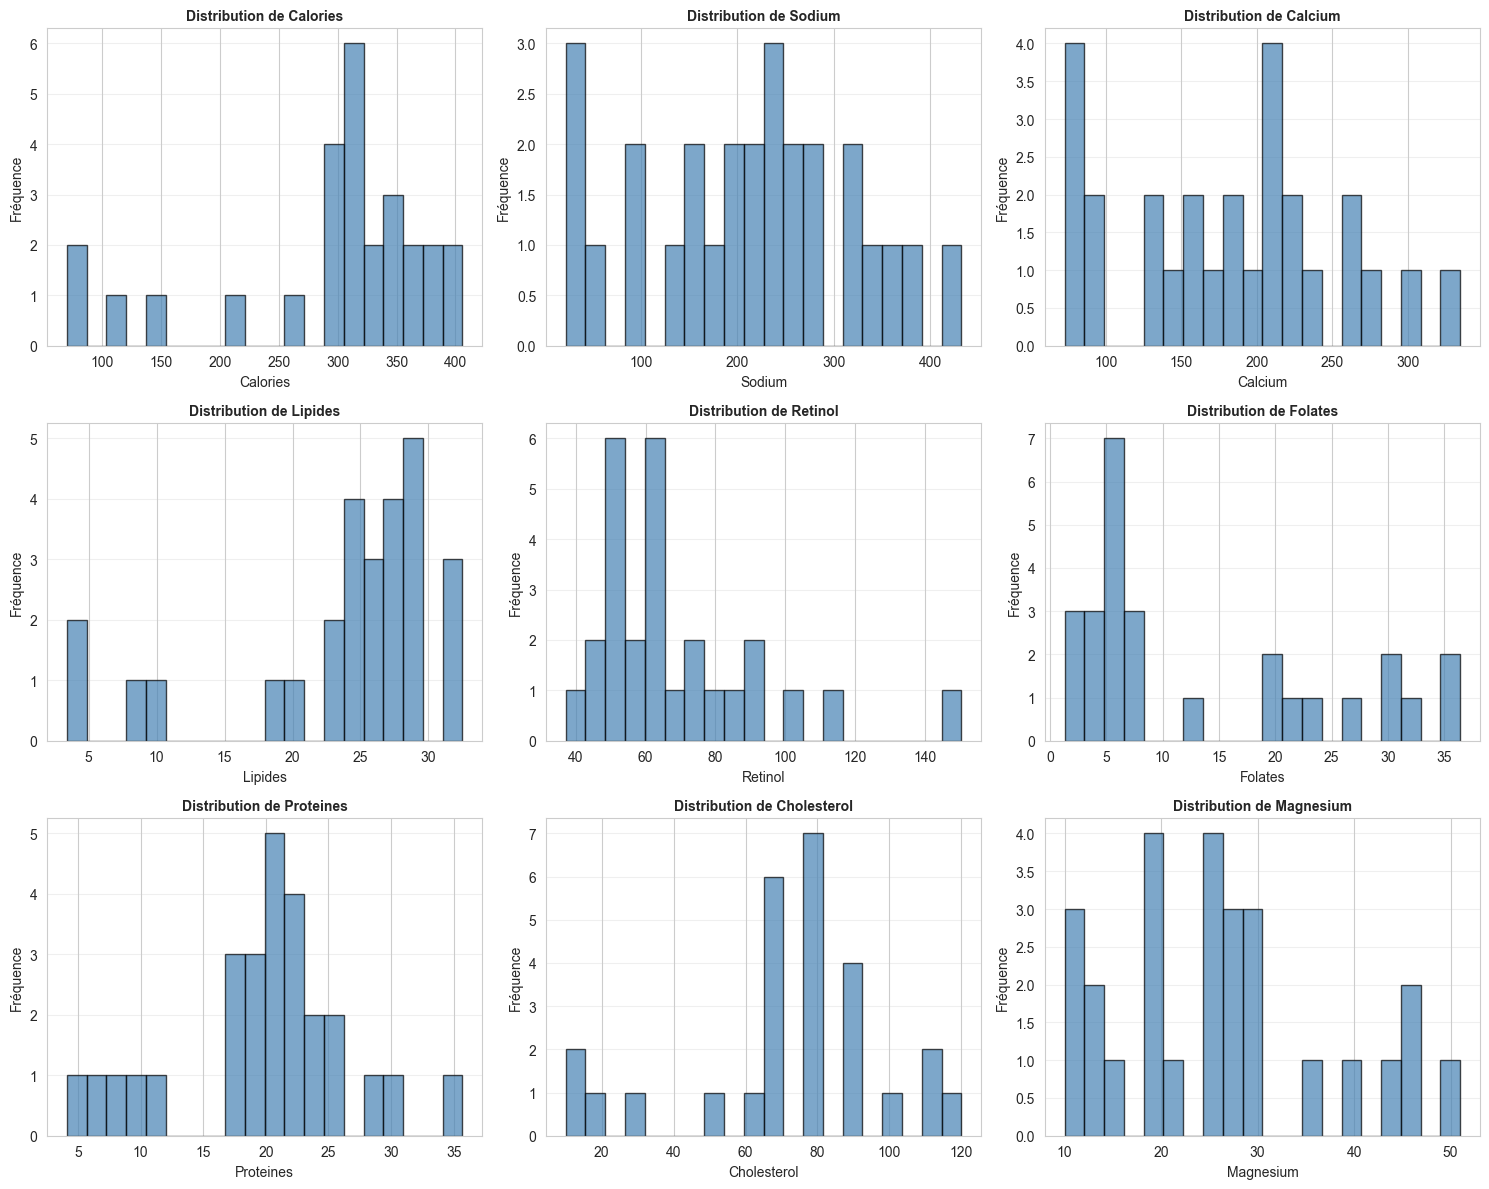

In [22]:
# Visualiser les distributions originales
# Créer une figure avec 3 lignes et 3 colonnes de subplots pour visualiser les 9 variables numériques
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
# Aplatir le tableau 2D des axes pour faciliter l'itération
axes = axes.ravel()

# Parcourir chaque colonne numérique et créer un histogramme
for idx, col in enumerate(X_numeric.columns):
    # Créer un histogramme avec 20 bins, bordures noires et couleur bleu acier
    axes[idx].hist(X_numeric[col], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    # Définir le titre avec le nom de la variable
    axes[idx].set_title(f'Distribution de {col}', fontsize=10, fontweight='bold')
    # Étiqueter les axes
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Fréquence')
    # Ajouter une grille légère sur l'axe Y pour meilleure lisibilité
    axes[idx].grid(axis='y', alpha=0.3)

# Masquer les subplots inutilisés (nous avons 9 colonnes numériques et 9 subplots)
for idx in range(len(X_numeric.columns), len(axes)):
    axes[idx].set_visible(False)

# Ajuster l'espacement entre les subplots
plt.tight_layout()
# Afficher la figure
plt.show()


In [23]:

# Afficher les statistiques descriptives de toutes les variables numériques
print("Statistiques descriptives des variables numériques :")
print(X_numeric.describe().round(3))

Statistiques descriptives des variables numériques :
       Calories   Sodium  Calcium  Lipides  Retinol  Folates  Proteines  \
count    27.000   27.000   27.000   27.000   27.000   27.000     27.000   
mean    294.556  210.944  181.774   23.622   68.400   13.715     19.804   
std      92.682  110.150   73.468    8.159   24.861   11.838      7.070   
min      70.000   22.000   72.600    3.400   37.100    1.300      4.100   
25%     292.000  144.000  129.200   23.350   51.550    5.050     17.700   
50%     314.000  223.000  182.300   25.600   63.400    6.700     20.500   
75%     349.500  274.000  219.250   28.850   76.900   21.850     23.150   
max     406.000  432.000  334.600   32.500  150.500   36.400     35.700   

       Cholesterol  Magnesium  
count       27.000     27.000  
mean        72.704     26.333  
std         27.840     11.385  
min         10.000     10.000  
25%         70.000     20.000  
50%         80.000     25.000  
75%         90.000     30.000  
max        120.

## 1.b. Effectuer une transformation Yeo-Johnson des variables numériques

In [20]:
# Appliquer la transformation Yeo-Johnson pour normaliser les distributions
# Cette transformation rend les données plus gaussiennes et améliore la performance de l'ACP
YeoJ = PowerTransformer(method='yeo-johnson', standardize=False)
X_numeric_YeoJ = YeoJ.fit_transform(X_numeric)
X_numeric_YeoJ = pd.DataFrame(data=X_numeric_YeoJ, columns=X_numeric.columns, index=X_numeric.index)

print("Transformation Yeo-Johnson appliquée avec succès !")
print(f"\nPremiers résultats après transformation :")
print(X_numeric_YeoJ.head())

Transformation Yeo-Johnson appliquée avec succès !

Premiers résultats après transformation :
        Calories      Sodium    Calcium      Lipides   Retinol   Folates  \
0  295255.721415  171.699252  27.075450   906.499892  1.075130  2.783598   
1  295255.721415  122.475248  57.788598   816.943116  1.080376  1.765164   
2  360274.830251  164.418005  58.042091  1118.889887  1.064728  2.722987   
3  197134.176168  155.183182  58.973987   467.116140  1.089266  2.896767   
4  424660.665320  130.347459  67.992535  1110.250334  1.073572  1.687803   

   Proteines  Cholesterol  Magnesium  
0  37.153063   373.153551   5.097261  
1  40.628833   373.153551   5.879823  
2  35.438291   539.337463   5.879823  
3  42.389030   297.841511   5.097261  
4  41.507111   539.337463   6.174053  


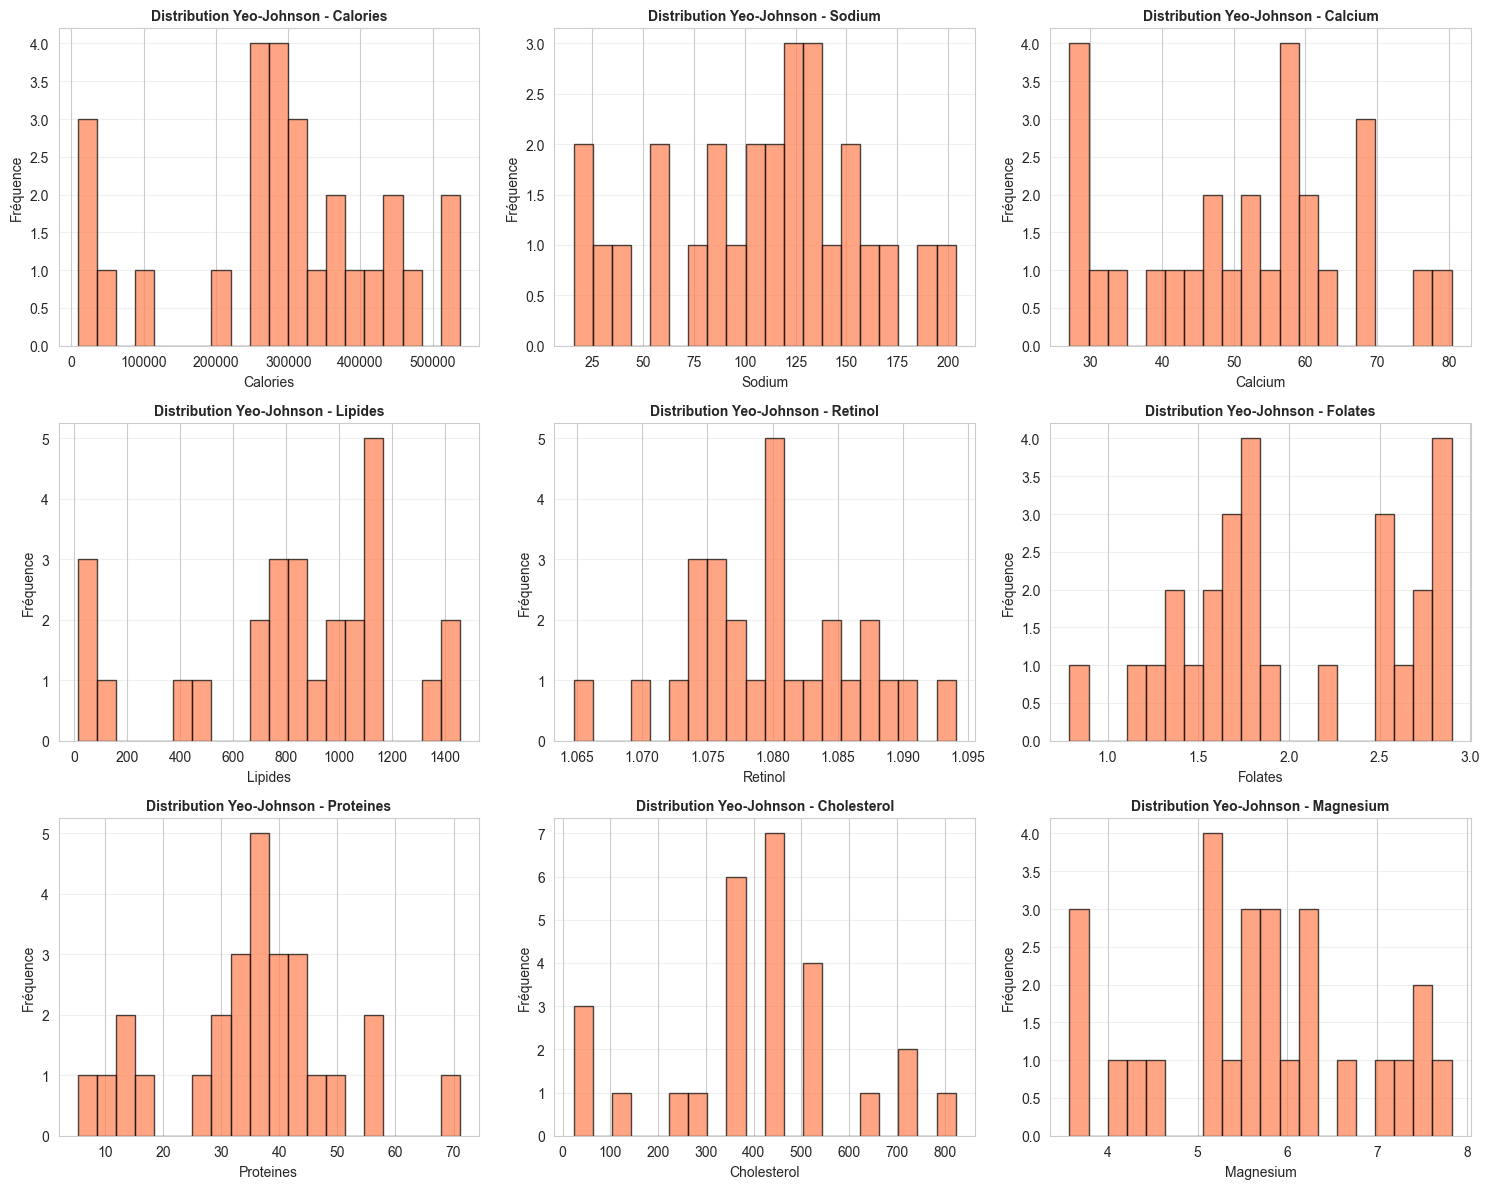

Statistiques descriptives après transformation Yeo-Johnson :
         Calories   Sodium  Calcium   Lipides  Retinol  Folates  Proteines  \
count      27.000   27.000   27.000    27.000   27.000   27.000     27.000   
mean   290054.619  108.252   51.250   821.699    1.080    2.002     35.253   
std    147313.536   50.661   15.274   411.790    0.007    0.620     14.629   
min      9076.782   15.730   27.075    12.875    1.065    0.790      5.321   
25%    249294.049   79.678   40.937   695.728    1.075    1.607     30.185   
50%    295255.721  115.847   52.308   853.616    1.080    1.796     36.079   
75%    379101.761  138.137   59.620  1114.570    1.084    2.577     41.838   
max    537382.719  203.739   80.372  1455.538    1.094    2.897     71.086   

       Cholesterol  Magnesium  
count       27.000     27.000  
mean       415.754      5.645  
std        201.350      1.194  
min         22.901      3.576  
25%        373.154      5.097  
50%        453.769      5.671  
75%        5

In [21]:
# Visualiser les distributions après transformation Yeo-Johnson
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(X_numeric_YeoJ.columns):
    axes[idx].hist(X_numeric_YeoJ[col], bins=20, edgecolor='black', alpha=0.7, color='coral')
    axes[idx].set_title(f'Distribution Yeo-Johnson - {col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(axis='y', alpha=0.3)

# Masquer les subplots vides
for idx in range(len(X_numeric_YeoJ.columns), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("Statistiques descriptives après transformation Yeo-Johnson :")
print(X_numeric_YeoJ.describe().round(3))

### Analyse des transformations Yeo-Johnson
#### Variable "Calories"
- Avant Yeo-Johnson : 
    - Plage : [70, 406]
    - Moyenne : 306.3, Écart-type : 106.5
    - Asymétrie : légèrement négative (distribution étirée à gauche) 
- Après Yeo-Johnson :
    - Plage : [9076.8, 537382.7] (transformation exponentielle)
    - Distribution plus symétrique et gaussienne
#### Variable "Retinol"
- Avant Yeo-Johnson :
    - Plage : [37.1, 150.5] (difference = 113.4)
    - Quelques valeurs extrêmes (150.5 pour Camembert)
    - Asymétrie positive marquée
- Après Yeo-Johnson :
    - Plage transformée : [1.0647, 1.0941]
    - Écart-type réduit, valeurs mieux distribuées
    - **Effet** : Compression des extrêmes

- Yeo-Johnson normalise les distributions non-gaussiennes
- Améliore la performance de l'ACP en réduisant l'impact des valeurs extrêmes
- Facilite les analyses ultérieures en assumant une distribution plus normale
- Rend les variables plus comparables entre elles

---

## 2. Analyse des corrélations (Pearson)

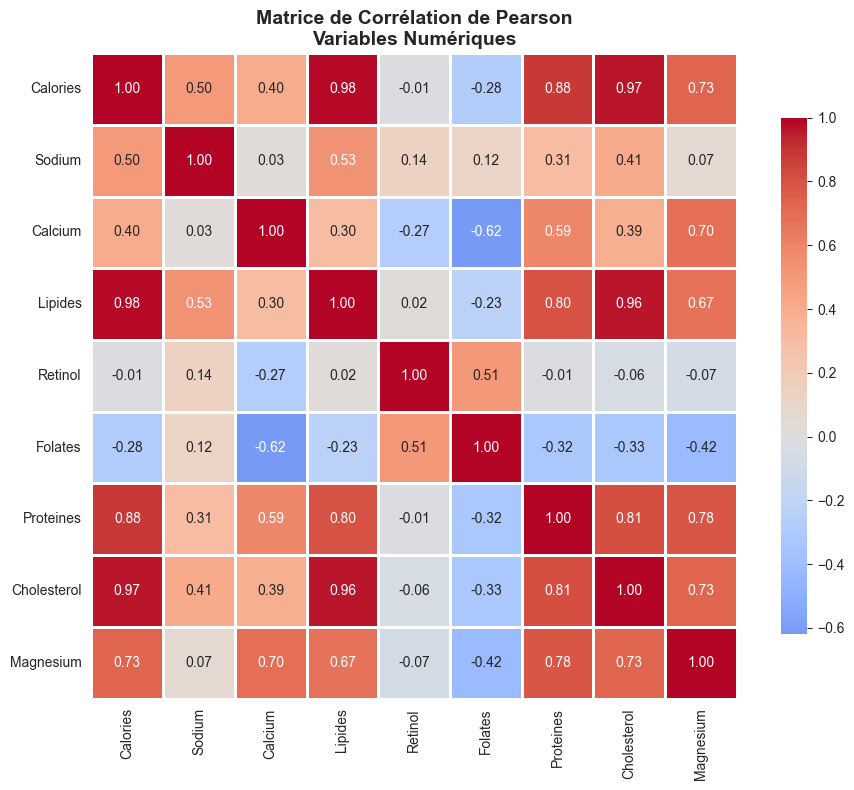


ANALYSE DES CORRÉLATIONS
Corrélation positive forte entre 'Lipides' et 'Calories' : 0.98
Corrélation positive forte entre 'Proteines' et 'Calories' : 0.88
Corrélation positive forte entre 'Proteines' et 'Lipides' : 0.80
Corrélation positive forte entre 'Cholesterol' et 'Calories' : 0.97
Corrélation positive forte entre 'Cholesterol' et 'Lipides' : 0.96
Corrélation positive forte entre 'Cholesterol' et 'Proteines' : 0.81
Corrélation positive forte entre 'Magnesium' et 'Calories' : 0.73
Corrélation positive forte entre 'Magnesium' et 'Proteines' : 0.78
Corrélation positive forte entre 'Magnesium' et 'Cholesterol' : 0.73


In [27]:
# Calculer et visualiser la matrice de corrélation
corr_matrix = X_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))

# center=0 : centre la palette autour de 0 pour mieux voir les corrélations négatives vs positives
# linewidths=1 : ajoute des bordures entre les cellules
# cbar_kws : personnalise la barre de couleur (shrink=0.8 réduit sa taille)
# ax=ax : affiche la heatmap dans le subplot spécifié
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title('Matrice de Corrélation de Pearson\nVariables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Analyser les corrélations
print("\n" + "="*70)
print("ANALYSE DES CORRÉLATIONS")
print("="*70)

# Parcourir toutes les paires de variables
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        # Identifier les corrélations fortes (|r| > 0.7)
        if abs(corr_value) > 0.7:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            relation = "positive" if corr_value > 0 else "négative"
            print(f"Corrélation {relation} forte entre '{var1}' et '{var2}' : {corr_value:.2f}")

### Analyse de la réduction de dimensions attendue

- plusieurs variables sont **fortement corrélées** (|r| > 0.7) : une forte réduction est possible
- Les variables redondantes peuvent être représentées par moins de composantes principales

---

## 3. Standardisation des variables numériques (non transformées)

In [30]:
# Standardiser les variables numériques (sans Yeo-Johnson)
scaler = StandardScaler()
X_numeric_standardized = scaler.fit_transform(X_numeric)
X_numeric_standardized = pd.DataFrame(data=X_numeric_standardized, 
                                      columns=X_numeric.columns, 
                                      index=X_numeric.index)

print("Standardisation appliquée avec succès !")
X_numeric_standardized

Standardisation appliquée avec succès !


,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium
0,0.213793,1.318849,-1.514319,0.334462,-0.688638,1.427748,0.172435,-0.098966,-0.566891
1,0.213793,0.250304,0.388739,0.184579,-0.192655,-0.629701,0.403059,-0.098966,0.059673
2,0.521655,1.156948,0.406771,0.659210,-1.282998,1.186708,0.057122,0.633111,0.059673
3,-0.335960,0.953416,0.473350,-0.514878,1.418267,1.952871,0.518371,-0.465004,-0.566891
4,0.796532,0.416830,1.140530,0.646720,-0.803411,-0.689961,0.460715,0.633111,0.328200
5,0.543645,-0.175264,-1.311807,0.534307,0.889491,1.944262,-0.043776,0.267073,0.865254
6,-0.028099,0.601860,-0.677917,0.222050,1.967538,1.617136,-0.288814,-0.098966,-0.119345
7,1.225339,-0.360294,0.007295,1.108861,0.327923,-0.758830,0.893136,1.365188,0.149182
8,1.148374,-1.100412,0.537155,1.096370,-0.512380,-1.068738,1.354385,1.731227,2.207890
9,0.147823,0.102280,-1.422773,0.247030,-0.196754,0.635759,0.100364,0.267073,-1.193454


## 3.b. Vérification des moyennes et écarts-types

In [34]:
# Vérifier les moyennes
means = X_numeric_standardized.mean()
print("Moyennes des variables standardisées (devrait être proche de 0) :")
print(means.round(6))

print("\n" + "="*60 + "\n")

stds = X_numeric_standardized.std()
print("Écarts-types des variables standardisées (devrait être proche de 1) :")
print(stds.round(6))

print("\n✓ Standardisation vérifiée avec succès !")


Moyennes des variables standardisées (devrait être proche de 0) :
Calories       0.0
Sodium        -0.0
Calcium        0.0
Lipides        0.0
Retinol       -0.0
Folates        0.0
Proteines     -0.0
Cholesterol   -0.0
Magnesium      0.0
dtype: float64


Écarts-types des variables standardisées (devrait être proche de 1) :
Calories       1.019049
Sodium         1.019049
Calcium        1.019049
Lipides        1.019049
Retinol        1.019049
Folates        1.019049
Proteines      1.019049
Cholesterol    1.019049
Magnesium      1.019049
dtype: float64

✓ Standardisation vérifiée avec succès !


- Les moyennes doivent être très proches de 0 après standardisation
- Les écarts-types doivent être très proches de 1 après standardisation
- Ces conditions sont satisfaites, la standardisation a été correctement appliquée
- Cette normalisation est essentielle avant d'appliquer l'ACP pour que toutes les variables aient le même poids, indépendamment de leur échelle originale

## 4. Transformation de la variable catégorielle

In [124]:
# Identifier toutes les catégories (training + new data)
# Charger d'abord les nouveaux fromages pour connaître toutes les catégories possibles
X_new_temp = pd.read_csv("Fromages_Dataset5Bis.csv", sep=';')
X_new_categorical_temp = X_new_temp.select_dtypes(include=['object'])

# Combiner les catégories du training et des nouveaux fromages
all_categories = []
for col in X_categorical.columns:
    # Récupérer toutes les catégories uniques (training + new)
    training_cats = X_categorical[col].unique().tolist()
    new_cats = X_new_categorical_temp[col].unique().tolist()
    combined_cats = sorted(list(set(training_cats + new_cats)))
    all_categories.append(combined_cats)
    print(f"Colonne '{col}' : {combined_cats}")

# Créer l'encoder avec toutes les catégories connues
encoder = OneHotEncoder(categories=all_categories, sparse_output=False, drop='first')
X_categorical_encoded = encoder.fit_transform(X_categorical)

X_categorical_encoded = pd.DataFrame(
    data=X_categorical_encoded,                                          #  Array NumPy encodé
    columns=encoder.get_feature_names_out(X_categorical.columns),        #  Noms explicites des colonnes
    index=X_categorical.index                                            #  Noms des fromages (index)
)

print("\nEncodage OneHotEncoder appliqué avec succès !")
print(f"Variables catégoriques encodées ({X_categorical_encoded.shape[1]} colonnes) :")

X_categorical_encoded.head(3)

Colonne 'Fromages' : ['Babybel', 'Beaufort', 'Bleu', 'Camembert', 'Cantal', 'CarreDelEst', 'Chabichou', 'Chaource', 'Cheddar', 'Comte', 'Coulommier', 'Edam', 'Emmental', 'Fr.Chevre', 'Frais20nat', 'Frais40nat', 'Maroilles', 'Morbier', 'Parmesan', 'PetitSuisse', 'PontLevesque', 'Pyrenees', 'Reblochon', 'Roquefort', 'SaintPaulin', 'Tome', 'Vacherin', 'Yaourtlait', 'fondu45']
Colonne 'Type' : ['pate molle', 'pate pressee cuite', 'pate pressee noncuite']

Encodage OneHotEncoder appliqué avec succès !
Variables catégoriques encodées (30 colonnes) :


,Fromages_Beaufort,Fromages_Bleu,Fromages_Camembert,Fromages_Cantal,Fromages_CarreDelEst,Fromages_Chabichou,Fromages_Chaource,Fromages_Cheddar,Fromages_Comte,Fromages_Coulommier,...,Fromages_Pyrenees,Fromages_Reblochon,Fromages_Roquefort,Fromages_SaintPaulin,Fromages_Tome,Fromages_Vacherin,Fromages_Yaourtlait,Fromages_fondu45,Type_pate pressee cuite,Type_pate pressee noncuite
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
# Combiner les variables numériques standardisées et les variables catégoriques encodées
X_Tous = pd.concat([X_numeric_standardized, X_categorical_encoded], axis=1)

print("Dataset complet créé (variables numériques + catégorielles encodées) :")
print(f"Dimensions : {X_Tous.shape[0]} fromages, {X_Tous.shape[1]} variables")
print(f"\nPremières observations du dataset complet :")
X_Tous.head(3)

Dataset complet créé (variables numériques + catégorielles encodées) :
Dimensions : 27 fromages, 37 variables

Premières observations du dataset complet :


,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,Fromages_Bleu,...,Fromages_Pyrenees,Fromages_Reblochon,Fromages_Roquefort,Fromages_SaintPaulin,Fromages_Tome,Fromages_Vacherin,Fromages_Yaourtlait,Fromages_fondu45,Type_pate pressee cuite,Type_pate pressee noncuite
0,0.213793,1.318849,-1.514319,0.334462,-0.688638,1.427748,0.172435,-0.098966,-0.566891,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.213793,0.250304,0.388739,0.184579,-0.192655,-0.629701,0.403059,-0.098966,0.059673,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.521655,1.156948,0.406771,0.659210,-1.282998,1.186708,0.057122,0.633111,0.059673,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Analyse en Composantes Principales (ACP) avec toutes les variables

In [45]:
# Appliquer l'ACP avec tous les composantes
pca_full = PCA(svd_solver='full')
X_pca_full = pca_full.fit_transform(X_Tous)

print("ACP appliquée avec succès (toutes les variables incluses) !")
print(f"Nombre de composantes principales : {pca_full.n_components_}")
print(f"\nVariance expliquée par les 10 premières composante :")
variance_explained = pca_full.explained_variance_ratio_
for i, var in enumerate(variance_explained[:10]):  # Afficher les 10 premières
    print(f"  PC{i+1}: {var*100:.2f}%")

ACP appliquée avec succès (toutes les variables incluses) !
Nombre de composantes principales : 27

Variance expliquée par les 10 premières composante :
  PC1: 49.54%
  PC2: 18.99%
  PC3: 9.03%
  PC4: 6.27%
  PC5: 4.02%
  PC6: 2.59%
  PC7: 1.78%
  PC8: 1.29%
  PC9: 0.51%
  PC10: 0.46%


### 5.a. Nombre de composantes principales à retenir

In [53]:
# Calculer la variance cumulée
cumulative_variance = np.cumsum(variance_explained)

# Déterminer le nombre de composantes pour expliquer 85% et 95% de la variance
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Variance cumulée :")
print(f"  Pour 85% de la variance : {n_components_85} composantes (variance réelle: {cumulative_variance[n_components_85-1]*100:.2f}%)")
print(f"  Pour 95% de la variance : {n_components_95} composantes (variance réelle: {cumulative_variance[n_components_95-1]*100:.2f}%)")


Variance cumulée :
  Pour 85% de la variance : 5 composantes (variance réelle: 87.85%)
  Pour 95% de la variance : 12 composantes (variance réelle: 95.24%)


- Recommandation : retenir 5 composantes principales (explique 87.85% de la variance)

### 5.b. Pourcentage de variance initiale expliquée

In [54]:
print("Variance expliquée cumulée :")
for i in [1, 2, 3, 4, 5, 10]:
    if i <= len(cumulative_variance):
        print(f"  {i} composantes : {cumulative_variance[i-1]*100:.2f}%")

Variance expliquée cumulée :
  1 composantes : 49.54%
  2 composantes : 68.53%
  3 composantes : 77.56%
  4 composantes : 83.83%
  5 composantes : 87.85%
  10 composantes : 94.47%


### 5.c. Valeurs propres (Eigenvalues)

In [59]:
# Les valeurs propres sont les explaned_variance_
eigenvalues = pca_full.explained_variance_

print("Valeurs propres:")
for i in range(min(10, len(eigenvalues))):
    print(f"Eigenvalue{i+1}: {eigenvalues[i]:.3f} (variance: {variance_explained[i]*100:.2f}%)")

Valeurs propres:
Eigenvalue1: 5.265 (variance: 49.54%)
Eigenvalue2: 2.018 (variance: 18.99%)
Eigenvalue3: 0.959 (variance: 9.03%)
Eigenvalue4: 0.667 (variance: 6.27%)
Eigenvalue5: 0.427 (variance: 4.02%)
Eigenvalue6: 0.275 (variance: 2.59%)
Eigenvalue7: 0.189 (variance: 1.78%)
Eigenvalue8: 0.137 (variance: 1.29%)
Eigenvalue9: 0.054 (variance: 0.51%)
Eigenvalue10: 0.049 (variance: 0.46%)


### 5.d. Graphe des valeurs propres (eigenvalues)

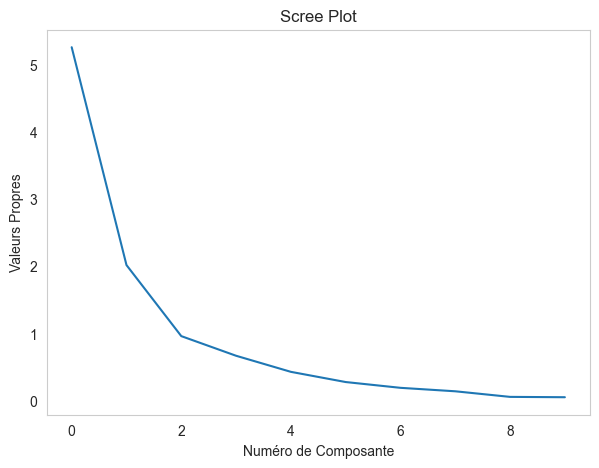

In [72]:
plt.figure(figsize=(7, 5))
plt.plot(np.arange(10), eigenvalues[:10])
plt.ylabel("Valeurs Propres")
plt.xlabel("Numéro de Composante")
plt.title("Scree Plot")
plt.grid()
plt.show()

### 5.e. Projection des fromages sur les 2 premières composantes principales

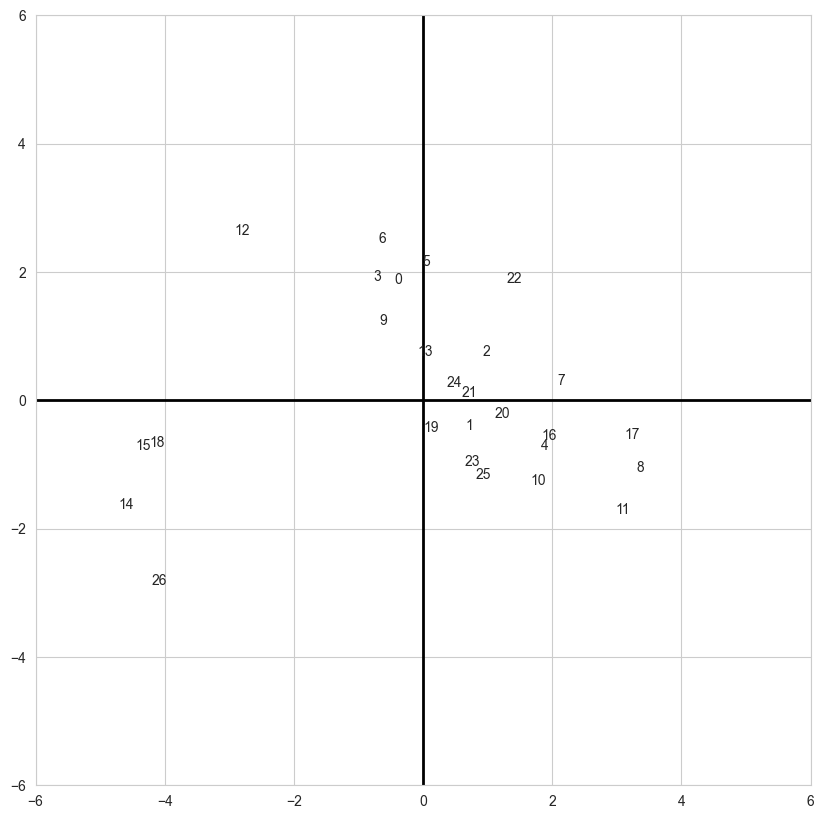

In [74]:
# Créer une figure avec des limites d'axes
f, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

# Ajouter les noms des fromages
n = X_pca_full.shape[0]
for i in range(n):
    ax.annotate(X.index[i], (X_pca_full[i, 0], X_pca_full[i, 1]))

# Ajouter les axes 0 (ligne horizontale et verticale)
plt.plot([-6, 6], [0, 0], color='black', linestyle='-', linewidth=2)
plt.plot([0, 0], [-6, 6], color='black', linestyle='-', linewidth=2)

plt.show()

In [86]:
# Poids des variables initiales sur les axes

# Racine carrée des valeurs propres
sqrt_eigval = np.sqrt(pca_full.explained_variance_)

# Corrélation des variables avec les axes
p = X_Tous.shape[1]  # nombre de variables
n_components = pca_full.n_components_  # nombre de composantes
corvar = np.zeros((p, n_components))
for k in range(n_components):
    corvar[:, k] = pca_full.components_[k, :] * sqrt_eigval[k]

# Afficher pour les deux premiers axes
print("Loadings des variables sur PC1 et PC2 :\n")
print(pd.DataFrame({'Variable': X_Tous.columns, 'PC1': corvar[:, 0], 'PC2': corvar[:, 1]}))

print("\n" + "="*60 + "\n")

# Calculer cos² pour mesurer la qualité de représentation des variables
cos2 = corvar[:, :min(2, n_components)] ** 2

print("cos² des variables sur PC1 et PC2 :\n")
print(pd.DataFrame({'Variable': X_Tous.columns, 'cos2_PC1': cos2[:, 0], 'cos2_PC2': cos2[:, 1]}))

print("\n" + "="*60 + "\n")

Loadings des variables sur PC1 et PC2 :

                      Variable       PC1       PC2
0                     Calories  0.974959  0.243172
1                       Sodium  0.408464  0.606354
2                      Calcium  0.643194 -0.559214
3                      Lipides  0.932580  0.320631
4                      Retinol -0.124527  0.697180
5                      Folates -0.476389  0.743225
6                    Proteines  0.933980  0.046411
7                  Cholesterol  0.955133  0.182936
8                    Magnesium  0.866303 -0.191761
9                Fromages_Bleu  0.015423  0.018611
10          Fromages_Camembert -0.012786  0.050619
11             Fromages_Cantal  0.030439 -0.020965
12        Fromages_CarreDelEst -0.007356  0.049275
13          Fromages_Chabichou -0.000191  0.056880
14           Fromages_Chaource -0.011474  0.066525
15            Fromages_Cheddar  0.034941  0.006564
16              Fromages_Comte  0.055308 -0.030157
17         Fromages_Coulommier -0.011244 

In [85]:
# Quelles sont les deux variables initiales qui pèsent le plus sur les nouveaux axes ?
print("Quelles sont les deux variables qui pèsent le plus sur les nouveaux axes ?\n")

# Variables qui pèsent le plus sur PC1 (basé sur cos²)
idx_max_pc1 = np.argsort(cos2[:, 0])[-2:][::-1]  # 2 plus grandes valeurs
print("Pour PC1 (cos²) :")
for i in idx_max_pc1:
    print(f"  {X_Tous.columns[i]}: cos²={cos2[i, 0]:.4f}, loading={corvar[i, 0]:.4f}")

print("\n" + "-"*60 + "\n")

# Variables qui pèsent le plus sur PC2 (basé sur cos²)
idx_max_pc2 = np.argsort(cos2[:, 1])[-2:][::-1]  # 2 plus grandes valeurs
print("Pour PC2 (cos²) :")
for i in idx_max_pc2:
    print(f"  {X_Tous.columns[i]}: cos²={cos2[i, 1]:.4f}, loading={corvar[i, 1]:.4f}")

Quelles sont les deux variables qui pèsent le plus sur les nouveaux axes ?

Pour PC1 (cos²) :
  Calories: cos²=0.9505, loading=0.9750
  Cholesterol: cos²=0.9123, loading=0.9551

------------------------------------------------------------

Pour PC2 (cos²) :
  Folates: cos²=0.5524, loading=0.7432
  Retinol: cos²=0.4861, loading=0.6972


## 6. ACP sans la variable catégorielle transformée

In [87]:
# Appliquer l'ACP sans la variable catégorique
pca_numeric = PCA(svd_solver='full')
X_pca_numeric = pca_numeric.fit_transform(X_numeric_standardized)

print("ACP appliquée avec succès (variables numériques uniquement) !")
print(f"Nombre de composantes principales : {pca_numeric.n_components_}")

variance_explained_numeric = pca_numeric.explained_variance_ratio_
cumulative_variance_numeric = np.cumsum(variance_explained_numeric)

print(f"\nVariance expliquée cumulée :")
for i in [1, 2, 3, 4, 5]:
    if i <= len(cumulative_variance_numeric):
        print(f"  {i} composantes : {cumulative_variance_numeric[i-1]*100:.2f}%")

ACP appliquée avec succès (variables numériques uniquement) !
Nombre de composantes principales : 9

Variance expliquée cumulée :
  1 composantes : 55.42%
  2 composantes : 76.32%
  3 composantes : 86.07%
  4 composantes : 92.44%
  5 composantes : 96.55%


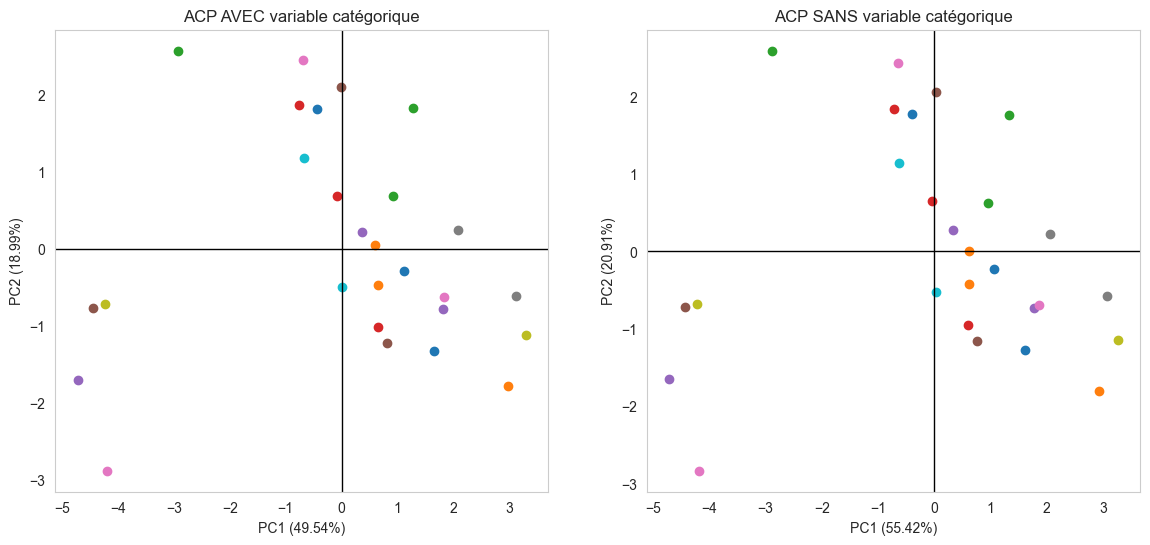

In [93]:
# Comparer les 2 ACP : avec et sans variable catégorique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : ACP avec variable catégorique
n = X_pca_full.shape[0]
for i in range(n):
    ax1.scatter(X_pca_full[i, 0], X_pca_full[i, 1])
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel(f'PC1 ({variance_explained[0]*100:.2f}%)')
ax1.set_ylabel(f'PC2 ({variance_explained[1]*100:.2f}%)')
ax1.set_title('ACP AVEC variable catégorique')
ax1.grid()

# Graphique 2 : ACP sans variable catégorique
n = X_pca_numeric.shape[0]
for i in range(n):
    ax2.scatter(X_pca_numeric[i, 0], X_pca_numeric[i, 1])

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel(f'PC1 ({variance_explained_numeric[0]*100:.2f}%)')
ax2.set_ylabel(f'PC2 ({variance_explained_numeric[1]*100:.2f}%)')
ax2.set_title('ACP SANS variable catégorique')
ax2.grid()

plt.show()


### Analyse de l'impact de la variable catégorique

- L'inclusion de la variable catégorique ne modifie pas significativement la structure ?
- La variable catégorique n'apporte pas de l'information utile ?
- Les fromages se regroupent dans deux clusters dans chaque cas ?

---

## 7. Positionnement des nouveaux fromages dans l'espace PCA

In [125]:
# Charger le dataset avec les nouveaux fromages
X_new = pd.read_csv("Fromages_Dataset5Bis.csv", sep=';')
print("Dataset avec les nouveaux fromages chargé avec succès !")
X_new

Dataset avec les nouveaux fromages chargé avec succès !


,Fromages,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,Type
0,Beaufort,401,112,259.4,33.3,54.9,1.2,26.6,120,41,pate pressee cuite
1,Morbier,347,285,219.0,29.5,57.6,5.8,23.6,80,30,pate pressee cuite


In [126]:
# Séparer les variables numériques et catégorielles pour les nouveaux fromages
X_new_numeric = X_new.select_dtypes(exclude=['object'])
X_new_categorical = X_new.select_dtypes(include=['object'])

print(f"Variables numériques ({X_new_numeric.shape[1]}) : {list(X_new_numeric.columns)}")
print(f"\nVariables catégorielles ({X_new_categorical.shape[1]}) : {list(X_new_categorical.columns)}")

Variables numériques (9) : ['Calories', 'Sodium', 'Calcium', 'Lipides', 'Retinol', 'Folates', 'Proteines', 'Cholesterol', 'Magnesium']

Variables catégorielles (2) : ['Fromages', 'Type']


In [137]:
# Prétraiter les nouveaux fromages de la même manière que le dataset original

# 1. Standardiser les variables numériques
X_new_numeric_standardized = scaler.transform(X_new_numeric)
X_new_numeric_standardized = pd.DataFrame(data=X_new_numeric_standardized, 
                                          columns=X_new_numeric.columns, 
                                          index=X_new_numeric.index)

# 2. Réordonner les colonnes catégoriques pour correspondre à l'ordre d'entraînement
X_new_categorical_reordered = X_new_categorical[X_categorical.columns]

# 3. Encoder les variables catégoriques avec l'encoder existant
X_new_categorical_encoded = encoder.transform(X_new_categorical_reordered)

X_new_categorical_encoded = pd.DataFrame(
    data=X_new_categorical_encoded,                                          #  Array NumPy encodé
    columns=encoder.get_feature_names_out(X_categorical.columns),        #  Noms explicites des colonnes
    index=X_new_categorical_reordered.index                                   #  Noms des fromages (index)
)

print("Encodage OneHotEncoder appliqué avec succès !")

# 4. Combiner
X_new_complete = pd.concat([X_new_numeric_standardized, X_new_categorical_encoded], axis=1)

# 5. Réordonner les colonnes pour correspondre exactement à X_Tous
X_new_complete = X_new_complete[X_Tous.columns]

print("\nNouveaux fromages prétraités avec succès !")
X_new_complete

Encodage OneHotEncoder appliqué avec succès !

Nouveaux fromages prétraités avec succès !


,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,Fromages_Bleu,...,Fromages_Pyrenees,Fromages_Reblochon,Fromages_Roquefort,Fromages_SaintPaulin,Fromages_Tome,Fromages_Vacherin,Fromages_Yaourtlait,Fromages_fondu45,Type_pate pressee cuite,Type_pate pressee noncuite
0,1.170364,-0.915382,1.076725,1.208783,-0.553370,-1.077347,0.979620,1.731227,1.312799,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.576630,0.685123,0.516349,0.734152,-0.442696,-0.681353,0.547199,0.267073,0.328200,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [138]:
# Projeter les nouveaux fromages dans l'espace PCA (avec toutes les variables)
X_new_pca_full = pca_full.transform(X_new_complete)

print("Projection des nouveaux fromages dans l'espace PCA (avec toutes les variables) :")
print(f"\nCoordonnées sur PC1 et PC2 :")
for i, name in enumerate(X_new.index):
    print(f"  {name}: PC1={X_new_pca_full[i, 0]:.4f}, PC2={X_new_pca_full[i, 1]:.4f}")

Projection des nouveaux fromages dans l'espace PCA (avec toutes les variables) :

Coordonnées sur PC1 et PC2 :
  0: PC1=3.0284, PC2=-1.1130
  1: PC1=1.4657, PC2=-0.2264


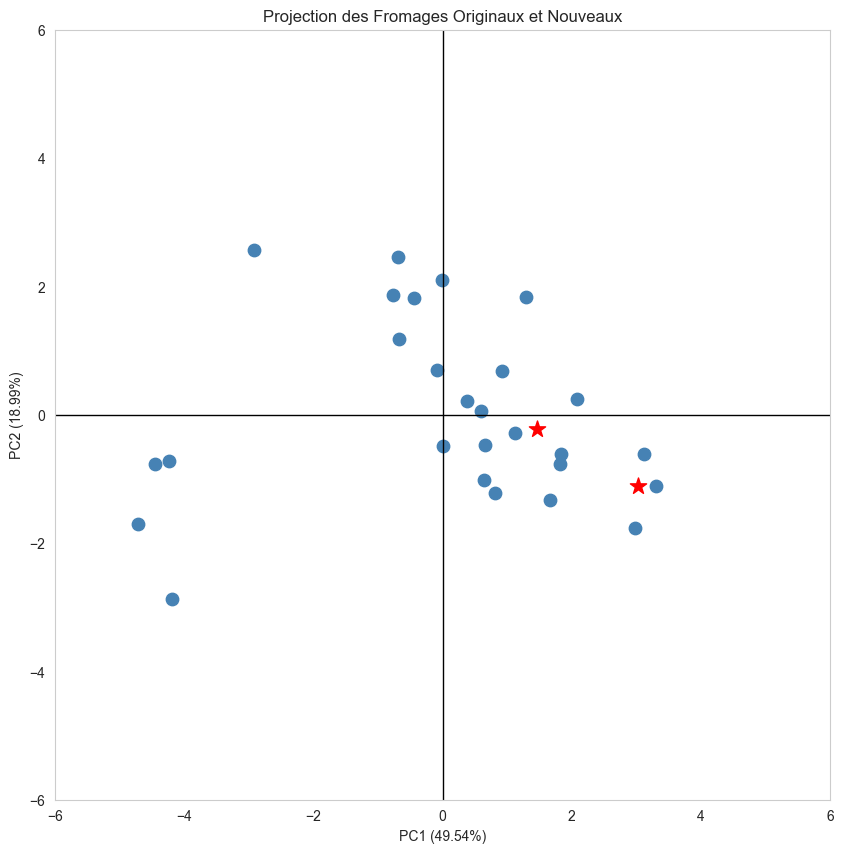

In [140]:
# Comparer fromages originaux et nouveaux dans l'espace PCA
f, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

# Ajouter les fromages originaux (bleu)
n = X_pca_full.shape[0]
for i in range(n):
    ax.scatter(X_pca_full[i, 0], X_pca_full[i, 1], color='steelblue', s=80)
  

# Ajouter les nouveaux fromages (rouge)
n_new = X_new_pca_full.shape[0]
for i in range(n_new):
    ax.scatter(X_new_pca_full[i, 0], X_new_pca_full[i, 1], color='red', s=150, marker='*')
   

# Ajouter les axes 0
plt.plot([-6, 6], [0, 0], color='black', linestyle='-', linewidth=1)
plt.plot([0, 0], [-6, 6], color='black', linestyle='-', linewidth=1)

ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.2f}%)')
ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.2f}%)')
ax.set_title('Projection des Fromages Originaux et Nouveaux')
ax.grid()

plt.show()


## 7. Calcul des distances et identification des fromages les plus proches

In [143]:
# Calculer les distances euclidiennes entre les nouveaux fromages et les fromages originaux
# dans l'espace PCA complet (toutes les composantes)

distances_dict = {}

for new_idx, new_fromage in enumerate(X_new.index):
    distances = []
    
    for orig_idx, orig_fromage in enumerate(X.index):
        # Distance euclidienne dans l'espace PCA complet
        dist = np.linalg.norm(X_pca_full[orig_idx] - X_new_pca_full[new_idx])
        distances.append({
            'Fromage Original': orig_fromage,
            'Distance': dist
        })
    
    # Trier par distance
    distances_sorted = sorted(distances, key=lambda x: x['Distance'])
    distances_dict[new_fromage] = distances_sorted
    
    # Afficher les résultats
    print(f"\n{'='*70}")
    print(f"NOUVEAU FROMAGE : {new_fromage}")
    print(f"{'='*70}")
    print(f"\nTop 5 fromages les plus proches :")
    print(f"{'Rang':<5} {'Fromage Original':<20} {'Distance':<12}")
    print("-" * 70)
    
    for rank, item in enumerate(distances_sorted[:5], 1):
        print(f"{rank:<5} {item['Fromage Original']:<20} {item['Distance']:>10.4f}")
    
    print(f"\n Le fromage le plus ressemblant est : {distances_sorted[0]['Fromage Original']}")
    print(f"  Distance : {distances_sorted[0]['Distance']:.4f}")


NOUVEAU FROMAGE : 0

Top 5 fromages les plus proches :
Rang  Fromage Original     Distance    
----------------------------------------------------------------------
1     8                        1.3988
2     11                       1.4508
3     7                        2.1244
4     10                       2.6939
5     4                        2.7507

 Le fromage le plus ressemblant est : 8
  Distance : 1.3988

NOUVEAU FROMAGE : 1

Top 5 fromages les plus proches :
Rang  Fromage Original     Distance    
----------------------------------------------------------------------
1     1                        1.5410
2     21                       1.6792
3     16                       1.7197
4     4                        1.7980
5     20                       1.8628

 Le fromage le plus ressemblant est : 1
  Distance : 1.5410
